In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
data = pd.read_csv("../../data/spring_2025_data/cleaned_alldata_with_urbanization.csv")

/var/folders/x5/n9435scx7nq7dwtr7ff8jcyc0000gn/T/ipykernel_36273/2132679078.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2020["Leaves_mature_dummy"] = (data_2020["Leaves_mature"] > 0).astype(int)


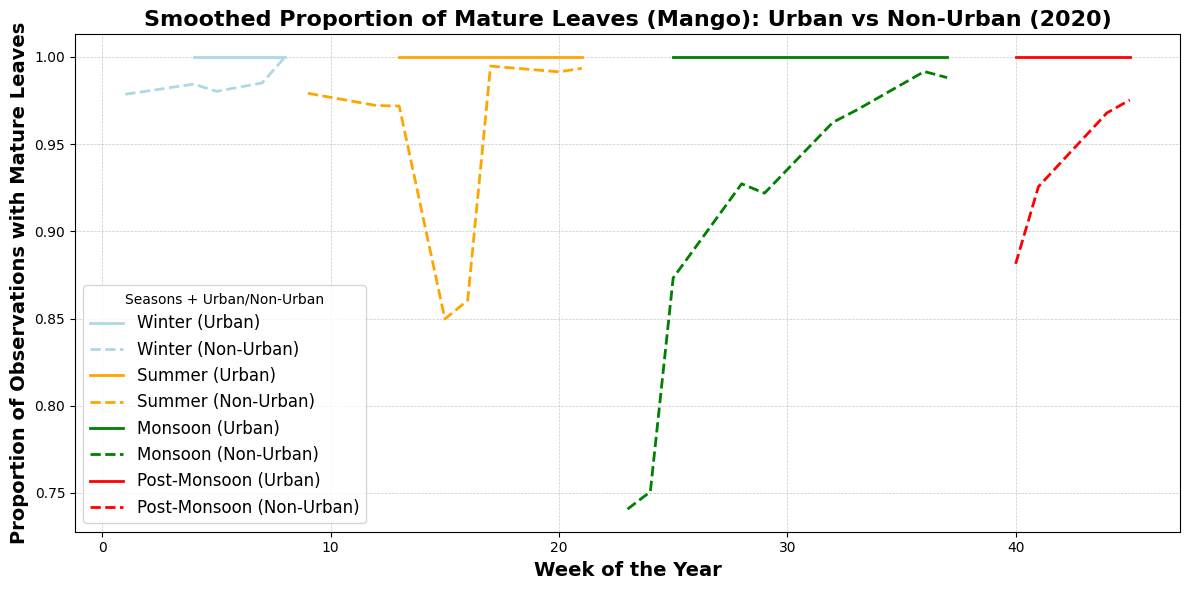

/Users/hrp/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


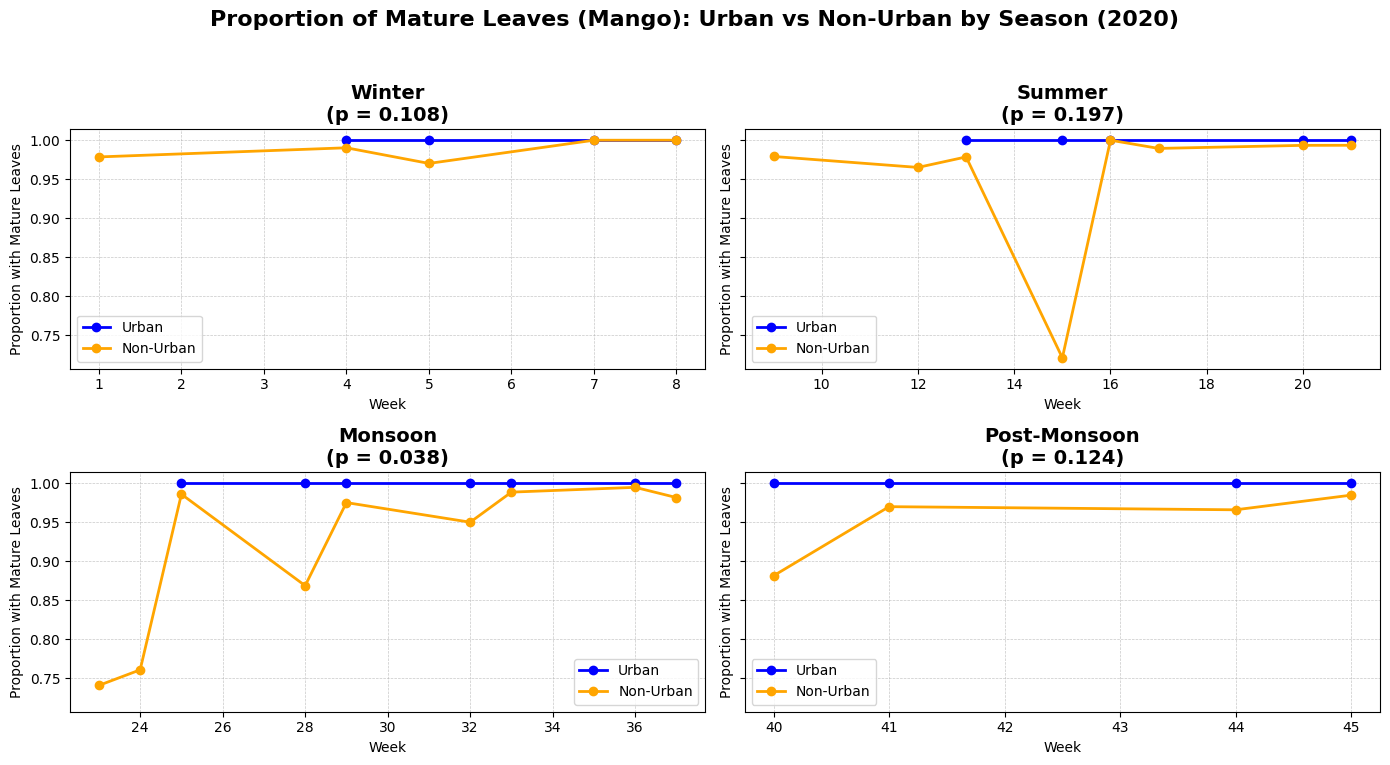

In [11]:
data_leaves_mature = data.copy()

data_2020 = data_leaves_mature[
    (data_leaves_mature["Year"] == 2020)
    & (data_leaves_mature["State_name"] == "Kerala")
    & (data_leaves_mature["Species_name"].str.contains("mango", case=False, na=False))
    & (data_leaves_mature["Leaves_mature"] >= 0)
]

data_2020["Leaves_mature_dummy"] = (data_2020["Leaves_mature"] > 0).astype(int)

# Split into urban and non-urban using 'high_radiance'
data_2020_urban = data_2020[data_2020["high_radiance"] == 1]
data_2020_non_urban = data_2020[data_2020["high_radiance"] == 0]

# Total and mature counts per week
urban_total = data_2020_urban.groupby("Week").size().reset_index(name="Total")
non_urban_total = data_2020_non_urban.groupby("Week").size().reset_index(name="Total")

urban_mature = (
    data_2020_urban.groupby("Week")["Leaves_mature_dummy"]
    .sum()
    .reset_index(name="Mature")
)
non_urban_mature = (
    data_2020_non_urban.groupby("Week")["Leaves_mature_dummy"]
    .sum()
    .reset_index(name="Mature")
)

# Merge and compute proportions
urban = pd.merge(urban_total, urban_mature, on="Week")
non_urban = pd.merge(non_urban_total, non_urban_mature, on="Week")
urban["Proportion"] = urban["Mature"] / urban["Total"]
non_urban["Proportion"] = non_urban["Mature"] / non_urban["Total"]

# Define seasons and colors
season_ranges = {
    "Winter": (1, 8),
    "Summer": (9, 22),
    "Monsoon": (23, 39),
    "Post-Monsoon": (40, 52),
}
season_colors = {
    "Winter": "lightblue",
    "Summer": "orange",
    "Monsoon": "green",
    "Post-Monsoon": "red",
}

# --- Smoothed Line Plot: Urban vs Non-Urban by Season ---
plt.figure(figsize=(12, 6))

for season, (start, end) in season_ranges.items():
    # Urban data
    urban_season = urban[(urban["Week"] >= start) & (urban["Week"] <= end)].copy()
    urban_season["Proportion_smooth"] = (
        urban_season["Proportion"].rolling(window=2, min_periods=1).mean()
    )
    plt.plot(
        urban_season["Week"],
        urban_season["Proportion_smooth"],
        linestyle="-",
        label=f"{season} (Urban)",
        linewidth=2,
        color=season_colors[season],
    )

    # Non-Urban data (same color, dashed)
    non_urban_season = non_urban[
        (non_urban["Week"] >= start) & (non_urban["Week"] <= end)
    ].copy()
    non_urban_season["Proportion_smooth"] = (
        non_urban_season["Proportion"].rolling(window=2, min_periods=1).mean()
    )
    plt.plot(
        non_urban_season["Week"],
        non_urban_season["Proportion_smooth"],
        linestyle="--",
        label=f"{season} (Non-Urban)",
        linewidth=2,
        color=season_colors[season],
    )

plt.title(
    "Smoothed Proportion of Mature Leaves (Mango): Urban vs Non-Urban (2020)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Week of the Year", fontsize=14, fontweight="bold")
plt.ylabel(
    "Proportion of Observations with Mature Leaves", fontsize=14, fontweight="bold"
)
plt.legend(title="Seasons + Urban/Non-Urban", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# --- Seasonal Subplots: Urban vs Non-Urban ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, (season, (start, end)) in enumerate(season_ranges.items()):
    urban_season = urban[(urban["Week"] >= start) & (urban["Week"] <= end)]
    non_urban_season = non_urban[
        (non_urban["Week"] >= start) & (non_urban["Week"] <= end)
    ]

    # Statistical test: only keep valid (non-NaN) data
    valid_urban = urban_season["Proportion"].dropna()
    valid_non_urban = non_urban_season["Proportion"].dropna()

    if len(valid_urban) > 1 and len(valid_non_urban) > 1:
        stat, p_value = ttest_ind(valid_urban, valid_non_urban, equal_var=False)
    else:
        p_value = float("nan")

    axes[i].plot(
        urban_season["Week"],
        urban_season["Proportion"],
        marker="o",
        color="blue",
        label="Urban",
        linewidth=2,
    )
    axes[i].plot(
        non_urban_season["Week"],
        non_urban_season["Proportion"],
        marker="o",
        color="orange",
        label="Non-Urban",
        linewidth=2,
    )

    axes[i].set_title(f"{season}\n(p = {p_value:.3f})", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Week")
    axes[i].set_ylabel("Proportion with Mature Leaves")
    axes[i].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    axes[i].legend()


fig.suptitle(
    "Proportion of Mature Leaves (Mango): Urban vs Non-Urban by Season (2020)",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


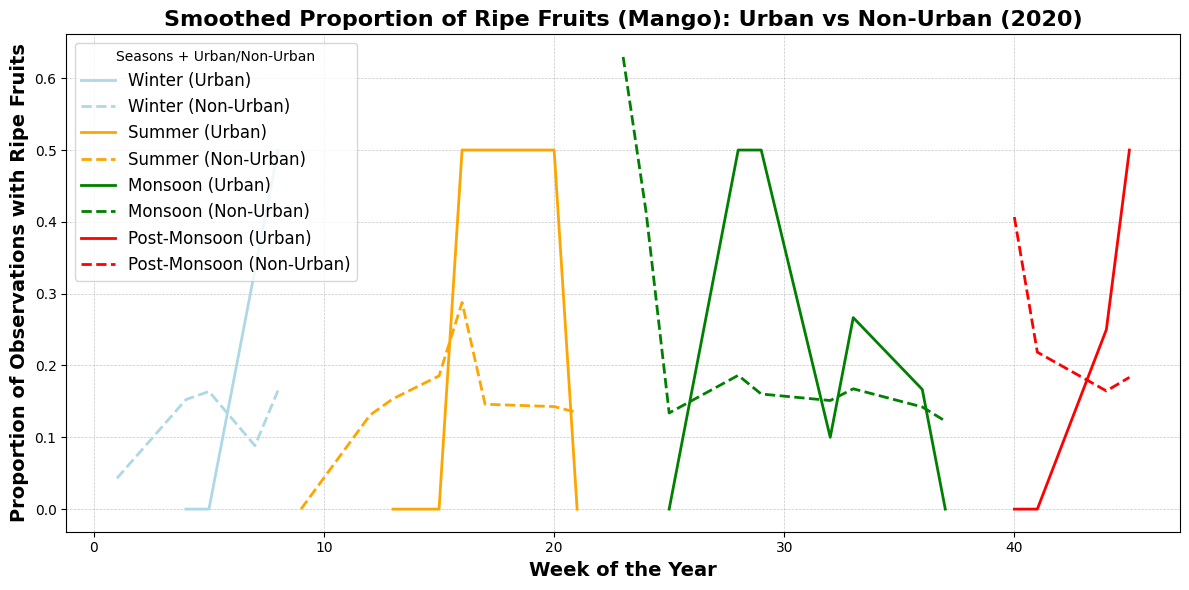

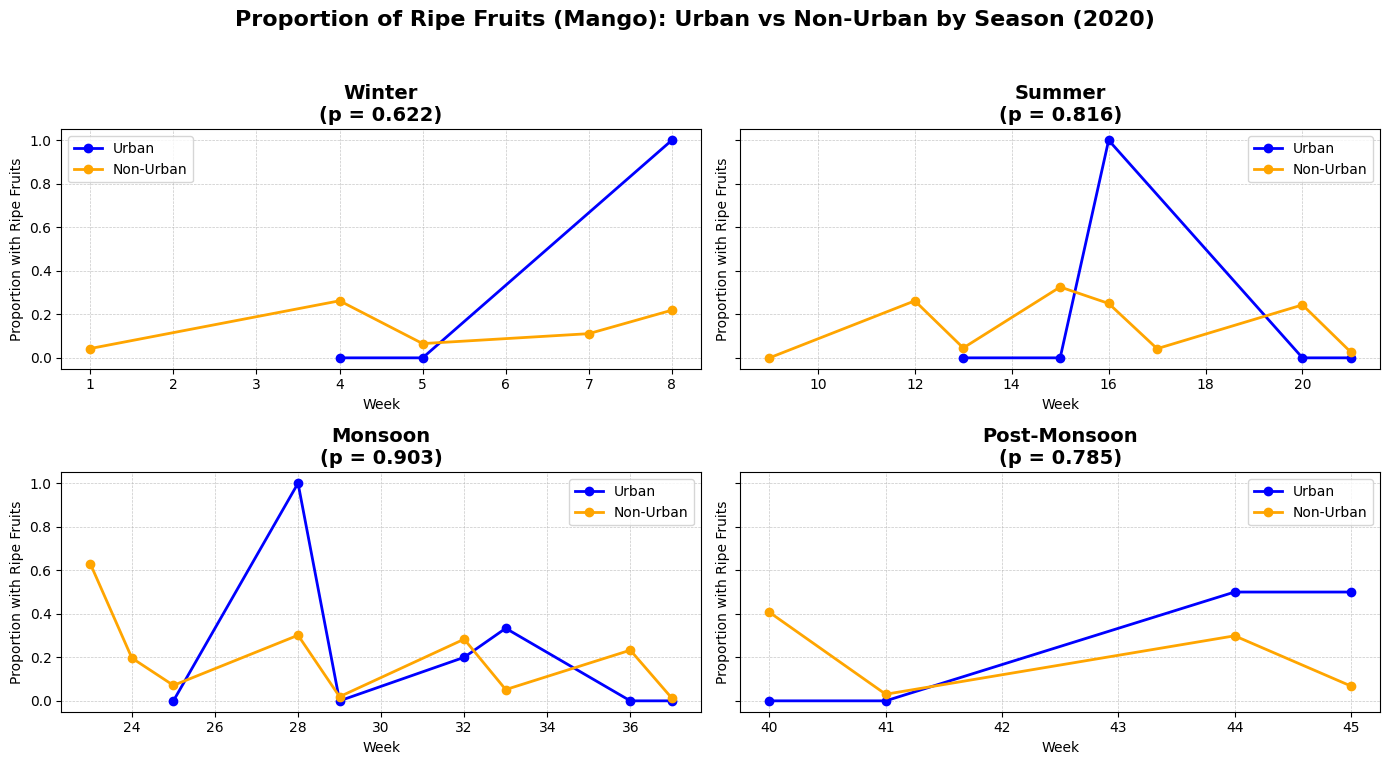

In [13]:
data_fruits_ripe = data.copy()

data_2020 = data_fruits_ripe[
    (data_fruits_ripe["Year"] == 2020)
    & (data_fruits_ripe["State_name"] == "Kerala")
    & (data_fruits_ripe["Species_name"].str.contains("mango", case=False, na=False))
    & (data_fruits_ripe["Fruits_ripe"] >= 0)  # Filter out values < 0 (null values)
]

data["fruits_ripe_dummy"] = (data["Fruits_ripe"] > 0).astype(int)

# Split into urban and non-urban using 'high_radiance'
data_2020_urban = data_2020[data_2020["high_radiance"] == 1]
data_2020_non_urban = data_2020[data_2020["high_radiance"] == 0]

# Total and mature counts per week
urban_total = data_2020_urban.groupby("Week").size().reset_index(name="Total")
non_urban_total = data_2020_non_urban.groupby("Week").size().reset_index(name="Total")

urban_mature = (
    data_2020_urban.groupby("Week")["fruits_ripe_dummy"]
    .sum()
    .reset_index(name="Mature")
)
non_urban_mature = (
    data_2020_non_urban.groupby("Week")["fruits_ripe_dummy"]
    .sum()
    .reset_index(name="Mature")
)

# Merge and compute proportions
urban = pd.merge(urban_total, urban_mature, on="Week")
non_urban = pd.merge(non_urban_total, non_urban_mature, on="Week")
urban["Proportion"] = urban["Mature"] / urban["Total"]
non_urban["Proportion"] = non_urban["Mature"] / non_urban["Total"]

# Define seasons and colors
season_ranges = {
    "Winter": (1, 8),
    "Summer": (9, 22),
    "Monsoon": (23, 39),
    "Post-Monsoon": (40, 52),
}
season_colors = {
    "Winter": "lightblue",
    "Summer": "orange",
    "Monsoon": "green",
    "Post-Monsoon": "red",
}

# --- Smoothed Line Plot: Urban vs Non-Urban by Season ---
plt.figure(figsize=(12, 6))

for season, (start, end) in season_ranges.items():
    # Urban data
    urban_season = urban[(urban["Week"] >= start) & (urban["Week"] <= end)].copy()
    urban_season["Proportion_smooth"] = (
        urban_season["Proportion"].rolling(window=2, min_periods=1).mean()
    )
    plt.plot(
        urban_season["Week"],
        urban_season["Proportion_smooth"],
        linestyle="-",
        label=f"{season} (Urban)",
        linewidth=2,
        color=season_colors[season],
    )

    # Non-Urban data (same color, dashed)
    non_urban_season = non_urban[
        (non_urban["Week"] >= start) & (non_urban["Week"] <= end)
    ].copy()
    non_urban_season["Proportion_smooth"] = (
        non_urban_season["Proportion"].rolling(window=2, min_periods=1).mean()
    )
    plt.plot(
        non_urban_season["Week"],
        non_urban_season["Proportion_smooth"],
        linestyle="--",
        label=f"{season} (Non-Urban)",
        linewidth=2,
        color=season_colors[season],
    )

plt.title(
    "Smoothed Proportion of Ripe Fruits (Mango): Urban vs Non-Urban (2020)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Week of the Year", fontsize=14, fontweight="bold")
plt.ylabel(
    "Proportion of Observations with Ripe Fruits", fontsize=14, fontweight="bold"
)
plt.legend(title="Seasons + Urban/Non-Urban", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# --- Seasonal Subplots: Urban vs Non-Urban ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, (season, (start, end)) in enumerate(season_ranges.items()):
    urban_season = urban[(urban["Week"] >= start) & (urban["Week"] <= end)]
    non_urban_season = non_urban[
        (non_urban["Week"] >= start) & (non_urban["Week"] <= end)
    ]

    # Statistical test: only keep valid (non-NaN) data
    valid_urban = urban_season["Proportion"].dropna()
    valid_non_urban = non_urban_season["Proportion"].dropna()

    if len(valid_urban) > 1 and len(valid_non_urban) > 1:
        stat, p_value = ttest_ind(valid_urban, valid_non_urban, equal_var=False)
    else:
        p_value = float("nan")

    axes[i].plot(
        urban_season["Week"],
        urban_season["Proportion"],
        marker="o",
        color="blue",
        label="Urban",
        linewidth=2,
    )
    axes[i].plot(
        non_urban_season["Week"],
        non_urban_season["Proportion"],
        marker="o",
        color="orange",
        label="Non-Urban",
        linewidth=2,
    )

    axes[i].set_title(f"{season}\n(p = {p_value:.3f})", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Week")
    axes[i].set_ylabel("Proportion with Ripe Fruits")
    axes[i].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    axes[i].legend()


fig.suptitle(
    "Proportion of Ripe Fruits (Mango): Urban vs Non-Urban by Season (2020)",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
